### Blog Generation

In [2]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import GoogleGenerativeAI
from typing import TypedDict
import os
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
GEMINI_KEY = os.getenv("GEMINI_API_KEY")

In [4]:
# Initialize LLM object
llm = GoogleGenerativeAI(api_key= GEMINI_KEY, model="gemini-2.5-flash-lite")

In [17]:
# Define State
class BlogState(TypedDict):
    title: str
    outline: str
    blog: str
    evaluation_score: int

In [18]:
def create_outline(state: BlogState) -> BlogState:
    title = state['title']
    outline = llm.invoke(f"Write me a detailed blog outline for title - {title}")
    state['outline'] = outline
    return state

def create_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']
    blog = llm.invoke(f"Write me a blog for title - {title} according to this outline - {outline}")
    state['blog'] = blog
    return state
def score(state: BlogState) -> BlogState:
    outline = state['outline']
    blog = state['blog']
    score = llm.invoke(f"Based on blog outline and blog generated by llm, give it a score out of 10, STRICTLY IN INTEGER ONLY.\n\nOUTLINE:\n{outline}\n\nBLOG\n{blog}")
    state['evaluation_score'] = score
    return state

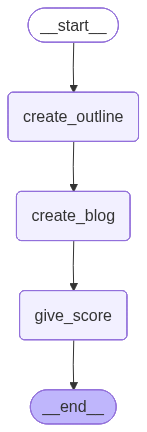

In [19]:
graph = StateGraph(BlogState)

# Create nodes
graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)
graph.add_node("give_score", score)

# Create Edges
graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_blog")
graph.add_edge("create_blog", "give_score")
graph.add_edge("give_score", END)

workflow = graph.compile()
workflow

In [20]:
final_state = workflow.invoke({"title": "Indias development in natural gas creation from coal"})

In [21]:
print(final_state['evaluation_score'])

9
